# Giovanni API NLDAS V2 Data Retrival formatted for BASINS Modeling

In [1]:
import earthaccess
import requests
import io
import pandas
import numpy as np
import matplotlib.pyplot as plt
from subprocess import Popen
import platform
import os
import shutil
from getpass import getpass
import netrc
from base64 import b64encode
from datetime import datetime

C:\Users\KVENABLE\OneDrive - Environmental Protection Agency (EPA)\HMS\NLDAS_3.0\EAT\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Establish files required for API Access

In [2]:
# Set homeDir to current working directory
homeDir = os.getcwd() + os.sep

# Create .urs_cookies and .dodsrc files in current directory
with open(homeDir + '.urs_cookies', 'w') as file:
    file.write('')
with open(homeDir + '.dodsrc', 'w') as file:
    file.write('HTTP.COOKIEJAR={}.urs_cookies\n'.format(homeDir))
    file.write('HTTP.NETRC={}.netrc'.format(homeDir))

print('Saved .urs_cookies and .dodsrc to:', homeDir)

# No need to copy .dodsrc since it's already in the working directory

Saved .urs_cookies and .dodsrc to: C:\Users\KVENABLE\OneDrive - Environmental Protection Agency (EPA)\HMS\NLDAS_3.0\


## Login with your Earthdata account. When completed your netrc file will be developed 

In [3]:
urs = 'urs.earthdata.nasa.gov'    # Earthdata URL to call for authentication
prompts = ['Enter NASA Earthdata Login Username \n(or create an account at urs.earthdata.nasa.gov): ',
           'Enter NASA Earthdata Login Password: ']

with open(homeDir + '.netrc', 'w') as file:
    file.write('machine {} login {} password {}'.format(urs, getpass(prompt=prompts[0]), getpass(prompt=prompts[1])))
    file.close()

print('Saved .netrc to:', homeDir)

# Set appropriate permissions for Linux/macOS
if platform.system() != "Windows":
    Popen('chmod og-rw ~/.netrc', shell=True)

Enter NASA Earthdata Login Username 
(or create an account at urs.earthdata.nasa.gov):  ········
Enter NASA Earthdata Login Password:  ········


Saved .netrc to: C:\Users\KVENABLE\OneDrive - Environmental Protection Agency (EPA)\HMS\NLDAS_3.0\


## Authenticate Credentials from login to generate token 

## Retrieve your token files

In [4]:
# Earthdata Login URL for obtaining the token, and creating one if it doesn't exist
url = 'https://urs.earthdata.nasa.gov/api/users/find_or_create_token'

# Earthdata Login credential prompts
prompts = ['Enter NASA Earthdata Login Username \n(or create an account at urs.earthdata.nasa.gov): ',
           'Enter NASA Earthdata Login Password: ']

# Get credentials from user input
auth = netrc.netrc(file=homeDir + '.netrc')
username, _, password = auth.authenticators('urs.earthdata.nasa.gov')

# Encode credentials using Base64
credentials = b64encode(f"{username}:{password}".encode('utf-8')).decode('utf-8')

# Headers with the Basic Authorization
headers = {
    'Authorization': f'Basic {credentials}'
}

# Make the POST request to get the token
response = requests.post(url, headers=headers)

# Check if the request was successful
if response.status_code == 200:
    # Parse the response JSON to get the token
    token_info = response.json()
    token = token_info.get("access_token")
    print("Token retrieved successfully")

    # Define the path for the .edl_token file in the home directory
    token_file_path = homeDir + ".edl_token"

    # Write the token to the .edl_token file
    with open(token_file_path, 'w') as token_file:
        token_file.write(token)

    print(f"Token saved to {token_file_path}")

else:
    print("Failed to retrieve token:", response.text)

Token retrieved successfully
Token saved to C:\Users\KVENABLE\OneDrive - Environmental Protection Agency (EPA)\HMS\NLDAS_3.0\.edl_token


# Create functions to retrieve the NLDAS Data through Giovanni API 

In [14]:
#Is this necessary?
#auth = earthaccess.login(persist="netrc")
#token = earthaccess.get_edl_token()['access_token']
#print('Earthdata Access is Granted')

Enter your Earthdata Login username:  epahms
Enter your Earthdata password:  ········


Earthdata Access is Granted


In [5]:
time_series_url = "https://api.giovanni.earthdata.nasa.gov/timeseries"

def call_time_series(lat,lon,time_start,time_end,data):
    """
    INPUTS:
    lat - latitude
    lon - longitude
    time_start - start of time series in YYYY-MM-DDThh:mm:ss format (UTC)
    end_time - end of the time series in YYYY-MM-DDThh:mm:ss format (UTC)
    data - name of the data parameter for the time series
    
    OUTPUT:
    time series csv output string
    """
    query_parameters = {
        "data":data,
        "location":"[{},{}]".format(lat,lon),
        "time":"{}/{}".format(time_start,time_end)
    }
   
    headers = {
    'Authorization': f'Bearer {token}'
    }
    
    response=requests.get(time_series_url, params=query_parameters, headers=headers)
    return response.text

In [6]:
def parse_csv(ts):
    """
    INPUTS:
    ts - time series output of the time series service
    
    OUTPUTS:
    headers,df - the headers from the CSV as a dict and the values in a pandas dataframe
    """
    with io.StringIO(ts) as f:
        # the first 13 rows are header
        headers = {}
        try:
            for i in range(13):
                line = f.readline()
                key,value = line.split(",")
                headers[key] = value.strip()
        except ValueError as e:
            raise ValueError(
                "The returned CSV is empty.\n"
                "Please ensure that your subsetting bounds are within the extent of your dataset\n"
                "or that your .netrc file is stored and contains valid credentials."
            ) from e

        # Read the csv proper
        df = pandas.read_csv(
            f,
            header=1,
            names=("Timestamp",headers["param_name"]),
            converters={"Timestamp":pandas.Timestamp}
        )

    return headers, df

In [7]:
import pandas as pd
import itertools
import json

def parse_csv2(ts):
    """
    Parse a CSV string, clean keys, extract headers and data.
    Returns:
        headers (dict): First 14 key-value pairs.
        df (pd.DataFrame): Data rows as DataFrame.
    """
    data_test = json.dumps(ts)
    lines = data_test.strip().split('\\n')
    data_dict = dict(line.split(",", 1) for line in lines if line)
    data_dict = {k.strip('[]'): v for k, v in data_dict.items()}
    data_dict = {k.strip('"'): v for k, v in data_dict.items()}
    headers = dict(itertools.islice(data_dict.items(), 14))
    df = pd.DataFrame.from_dict(data_dict, orient="index", columns=["Data"]).reset_index()
    df = df[15:-1].rename(columns={'index': 'Timestamp (UTC)'}).reset_index(drop=True)
    return headers, df


In [8]:
def prompt_for_nldas_inputs():
    """
    Prompts the user to enter latitude, longitude, beginning date, and ending date.
    Returns:
        lat (float), lon (float), time_start (str), time_end (str)
    """
    while True:
        try:
            lat = float(input("Enter latitude (e.g., 46.6875): "))
            break
        except ValueError:
            print("Invalid latitude. Please enter a number.")
    while True:
        try:
            lon = float(input("Enter longitude (e.g., -94.0625): "))
            break
        except ValueError:
            print("Invalid longitude. Please enter a number.")
    time_start = input("Enter beginning date (YYYY-MM-DDTHH:MM:SS): ")
    time_end = input("Enter ending date (YYYY-MM-DDTHH:MM:SS): ")
    return lat, lon, time_start, time_end

# Example usage:
lat, lon, time_start, time_end = prompt_for_nldas_inputs()
print(lat, lon, time_start, time_end)


Enter latitude (e.g., 46.6875):  33.6367
Enter longitude (e.g., -94.0625):  -84.4281
Enter beginning date (YYYY-MM-DDTHH:MM:SS):  2000-01-01T00:00:00
Enter ending date (YYYY-MM-DDTHH:MM:SS):  2024-12-31T23:00:00


33.6367 -84.4281 2000-01-01T00:00:00 2024-12-31T23:00:00


# For new EarthData User's you will need to copy the hyper link below and place into a browser to accept the terms and conditions of using the NASA GESDISC Data Archive and will need to login to the EarthData website

In [9]:
#https://api.giovanni.earthdata.nasa.gov/proxy-timeseries?data=NLDAS_FORA0125_H_2_0_Rainf&location=[46.6875,-93.0625]&time=2010-01-01T01:00:00/2025-10-24T23:00:00&version=2.0 

## Parser for ArcGIS parse_csv2(remove hashtag and place one below in front of the headers,df)

In [10]:
class NLDASData:
    prefix = "NLDAS_FORA0125_H_2_0_"

    def __init__(self, lat, lon, time_start, time_end):
        self.lat = lat
        self.lon = lon
        self.time_start = time_start
        self.time_end = time_end

    @property
    def data(self):
        return self.prefix + self.suffix

    def fetch(self, export_path=None):
        ts = call_time_series(self.lat, self.lon, self.time_start, self.time_end, self.data)
        # Get the current local date and time as a datetime object
        current_datetime = datetime.now()
        current_datetime_no_decimals = datetime.now().replace(microsecond=0)
        request_time_col = str(current_datetime_no_decimals)
        #parser for ArcGIS parse_csv2(remove hashtag and place one below in front of the headers,df)
        #headers, df = parse_csv2(ts)
        headers, df = parse_csv(ts)
        headers['Request_time'] = request_time_col
        b_dt = datetime.strptime(headers['begin_time'], '%Y-%m-%d %H:%M:%S')
        e_dt = datetime.strptime(headers['end_time'], '%Y-%m-%d %H:%M:%S')
        if export_path is None:
            filename = str(headers['param_short_name']) + ".Lng" + str(headers['lon']) + ".Lat" +  str(headers['lat']) +"_" +str(b_dt.strftime('%Y-%m-%dT%H')) + "to" + str(e_dt.strftime('%Y-%m-%dT%H')) + ".nldas"
            #export_path = os.path.join(os.getcwd(), f"{filename}.csv")
            export_path = os.path.join(os.getcwd(), f"{filename}.txt")
        # Add to headers dictionary
        headers_df = pd.DataFrame.from_dict(headers, orient="index", columns=["Value"]).reset_index()
        headers_df.to_csv(export_path, index = False, sep=',', header=False)

        # Write a blank line (if needed)
        with open(export_path, 'a') as f:
            f.write('\n')
        df.columns = ["Timestamp (UTC)", "Data"]
        df.to_csv(export_path, mode = 'a', index=False , sep=',')
        return headers, df


class WindE(NLDASData):
    suffix = "Wind_E"

class Rainf(NLDASData):
    suffix = "Rainf"

class Tair(NLDASData):
    suffix = "Tair"

class SWdown(NLDASData):
    suffix = "SWdown"

class LWdown(NLDASData):
    suffix = "LWdown"

class WindN(NLDASData):
    suffix = "Wind_N"
    
class Qair(NLDASData):
    suffix = "Qair"

# Usage:
#wind_e = WindE(lat, lon, time_start, time_end)
#headers, df = wind_e.fetch()


## Acquire Zonal Wind Speed (Enter Latitude, Longitude, Begin Date, and End Date) 
## e.g. (46.6875, -94.0625, "2010-01-01T01:00:00", "2025-10-24T23:00:00")

In [11]:
wind_e = WindE(lat, lon, time_start, time_end)
headers, df = wind_e.fetch()

## Acquire Total Precipitation (Enter Latitude, Longitude, Begin Date, and End Date)

In [12]:
rain = Rainf(lat, lon, time_start, time_end)
headers, df = rain.fetch()

## Acquire Air Temperature (Enter Latitude, Longitude, Begin Date, and End Date)

In [13]:
airt = Tair(lat, lon, time_start, time_end)
headers, df = airt.fetch()

## Acquire Shortwave Radiation (Enter Latitude, Longitude, Begin Date, and End Date)

In [14]:
swd= SWdown(lat, lon, time_start, time_end)
headers, df = swd.fetch()

## Acquire Longwave Radition (Enter Latitude, Longitude, Begin Date, and End Date)

In [15]:
lwd= LWdown(lat, lon, time_start, time_end)
headers, df = lwd.fetch()

## Acquire Meridional Wind Speed  (Enter Latitude, Longitude, Begin Date, and End Date)

In [16]:
wind_n= WindN(lat, lon, time_start, time_end)
headers, df = wind_n.fetch()

## Acquire Specific Humidity  (Enter Latitude, Longitude, Begin Date, and End Date)

In [17]:
qair= Qair(lat, lon, time_start, time_end)
headers, df = qair.fetch()

## Ploting Example with Specific Humidity 

Text(0.5, 1.0, 'Qair at [33.6875,-84.4375]')

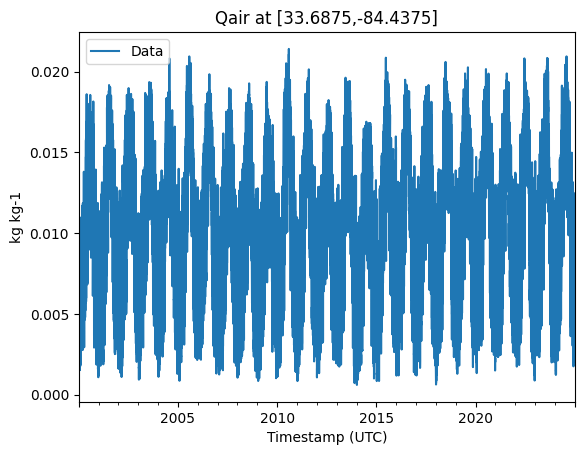

In [18]:
ax = plt.gca()
df_plot = df[16::].reset_index()
df_plot.plot(x="Timestamp (UTC)",y="Data",ax=ax)
ax.set_ylabel(headers["unit"])
ax.set_title("{} at [{},{}]".format(headers["param_short_name"],headers["lat"],headers["lon"]))

## Calculate Statistics for singular Parameter (Qair) 

In [19]:
df_plot.describe()

,index,Timestamp (UTC),Data
count,219152.000000,219152,219152.000000
mean,109591.500000,2012-07-02 07:30:00,0.009812
min,16.000000,2000-01-01 16:00:00,0.000608
25%,54803.750000,2006-04-02 11:45:00,0.005498
50%,109591.500000,2012-07-02 07:30:00,0.009845
75%,164379.250000,2018-10-02 03:15:00,0.014039
max,219167.000000,2024-12-31 23:00:00,0.021404
std,63263.877434,NaN,0.004734
